# Initalization

In [1]:
%matplotlib inline

In [33]:
import numpy as np
import warnings
warnings.filterwarnings('ignore', message='No contour levels were found')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

import sys
sys.path.append('../../../tools/analysis/')
# m6toolbox is a python package that has a function that helps visualize vertical sections
import m6toolbox

# a collection of useful python modules
sys.path.insert(0, '../python')

import pittwolfe as pw
import pittwolfe.timeseries as ts
from pittwolfe.util import sind, cosd


# Function definitions

<GeoAxesSubplot:>

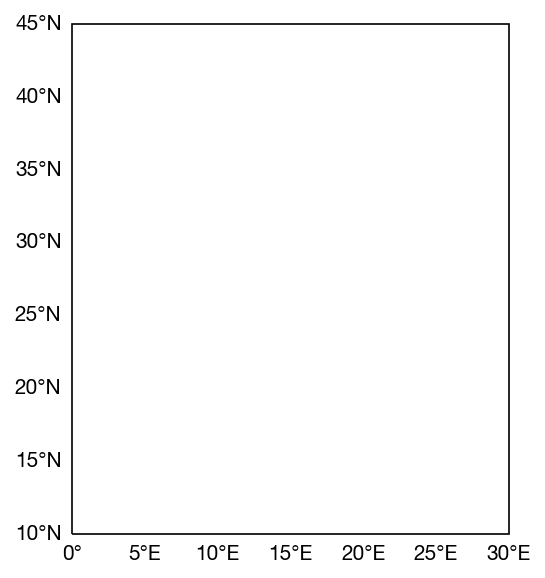

In [34]:
def setup_plan_plot(ax=None, bottom_labels=True, left_labels=True):
    data_projection = ccrs.PlateCarree()
    map_projection = ccrs.PlateCarree()
#     map_projection = ccrs.AlbersEqualArea(central_longitude=15, 
#                                           central_latitude=25,
#                                           standard_parallels=(20.0, 50.0))

    if ax is None:
        ax = plt.axes(projection=map_projection)

    ax.set_extent([-0.001, 30.001, 9.999, 45.0001], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = bottom_labels
    gl.left_labels = left_labels
    gl.xlines = False
    gl.ylines = False

    vertices = [
        [ 0, 10],
        [30, 10],
        [30, 45],
        [ 0, 45],
        [ 0, 10]
    ]

    path = mpath.Path(vertices).interpolated(20)

#     ax.background_patch.set_facecolor('.5')
#     xlocs = np.arange(-90, 240, 30)
#     ylocs = np.arange(-75, 90, 15)
#     ax.gridlines(xlocs=xlocs, ylocs=ylocs, linewidth=.5)
#     ax.set_boundary(path, transform=data_projection)
    
    return ax

setup_plan_plot()

# Load datasets

## Constants

In [35]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [36]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [37]:
grid = xr.open_dataset('OUTPUT/ocean_geometry.nc').rename(coord_map_h)
ic = xr.open_dataset('OUTPUT/MOM_IC.nc').squeeze().rename({**coord_map_h, **coord_map_v})

Nx = len(grid.xh)
Ny = len(grid.yh)

grid['zi'] = ic.zi
grid['zl'] = ic.zl

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid['maskH'] = grid.wet
grid['maskU'] = (['yh', 'xq'], np.ones((Ny, Nx+1)))
grid['maskU'][:,[0, -1]] = 0
grid['maskV'] = (['yq', 'xh'], np.ones((Ny+1, Nx)))
grid['maskV'][[0, -1],:] = 0


grid

<xarray.Dataset>
Dimensions:  (yh: 81, xh: 60, yq: 82, xq: 61, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/26)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    fq       (yq) float64 2.532e-05 2.655e-05 2.778e-05 ... 0.0001025 0.0001032
    βh       (yh) float64 2.252e-11 2.249e-11 2.245e-11 ... 1.632e-11 1.622e-11
    βq       (yq) float64 2.254e-11 2.251e-11 2.247e-11 ... 1.627e-11 1.617e-11
    maskH    (yh, xh) float64 ...
    maskU    (yh, xq) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    maskV    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    filename:  ./ocean_geometry.nc

In [38]:
grid_op = xgcm.Grid(grid, periodic=False, boundary='fill', fill_value=0, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, boundary='fill'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, boundary='fill'):
  * inner    zl
  * outer    zi

## Forcing

In [39]:
forcing = xr.open_dataset('INPUT/forcing.nc')

# make sure the coordinates match exactly
forcing['xh'] = grid.xh 
forcing['xq'] = grid.xq[:-1]
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
    Time      timedelta64[ns] 00:00:00
Data variables:
    STRESS_X  (yh, xq) float64 ...
    STRESS_Y  (yq, xh) float64 ...

## Statistics

In [44]:
stats.close()

In [45]:
stats = xr.open_dataset('OUTPUT/ocean.stats.nc')
stats

<xarray.Dataset>
Dimensions:        (Layer: 2, Interface: 3, Time: 36001)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.036e+03
  * Interface      (Interface) float64 1.034e+03 1.036e+03 1.037e+03
  * Time           (Time) timedelta64[ns] 0 days 1 days ... 36000 days
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [46]:
prog.close()

In [47]:
prog = xr.open_mfdataset('OUTPUT/prog*.nc')
prog

<xarray.Dataset>
Dimensions:  (xq: 61, yh: 81, zl: 2, time: 100, xh: 60, yq: 82, zi: 3)
Coordinates:
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl       (zl) float64 1.035e+03 1.036e+03
  * time     (time) object 0002-01-01 00:00:00 ... 0101-01-01 00:00:00
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
Data variables:
    u        (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    v        (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    h        (time, zl, yh, xh) float64 dask.array<chunksize=(10, 2, 81, 60), meta=np.ndarray>
    e        (time, zi, yh, xh) float32 dask.array<chunksize=(10, 3, 81, 60), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

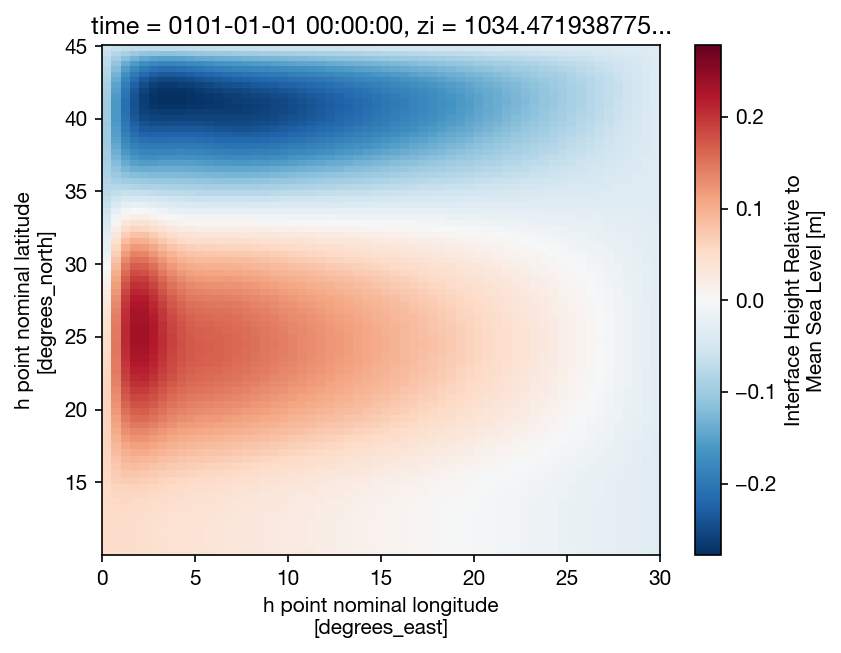

In [48]:
pc = (prog.e.isel(time=-1, zi=0)).plot()

# Plot

## Statistics

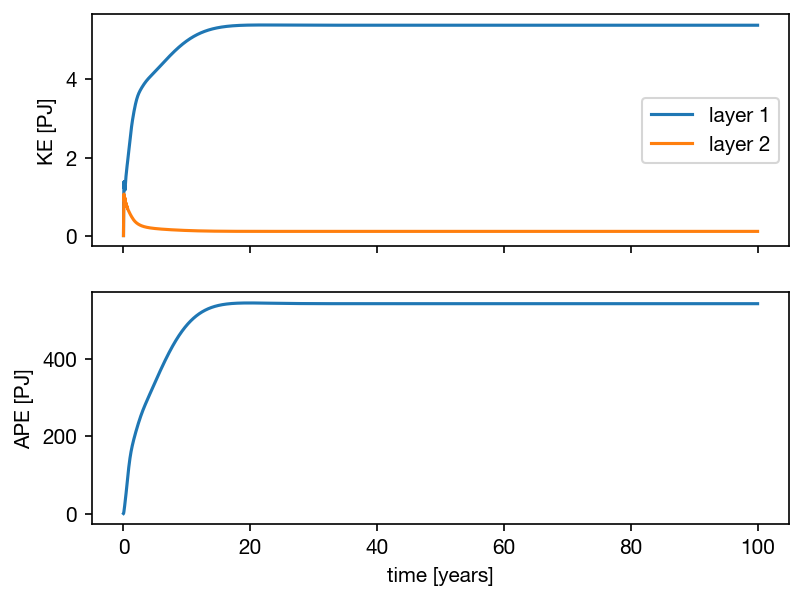

In [49]:
years = np.arange(len(stats.Time))/360

fig, axs = plt.subplots(nrows=2, sharex=True)

ax = axs[0]
ax.plot(years, stats.KE.isel(Layer=0)/1e15, label='layer 1')
ax.plot(years, stats.KE.isel(Layer=1)/1e15, label='layer 2')
ax.legend()
ax.set_ylabel('KE [PJ]')

ax = axs[1]
ax.plot(years, stats.APE.isel(Interface=1)/1e15)
ax.set_ylabel('APE [PJ]')
ax.set_xlabel('time [years]')

fig.savefig('energy.pdf', bbox_inches='tight')

## SSH

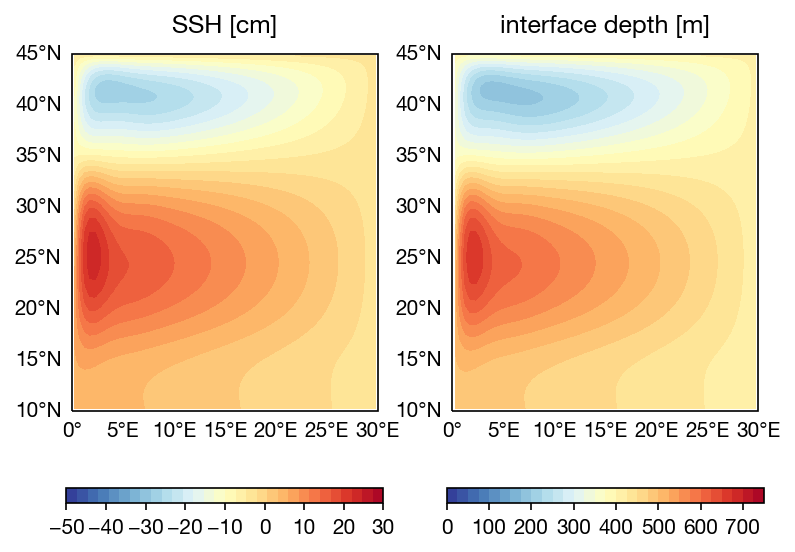

In [50]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, 
                        subplot_kw={'projection': ccrs.PlateCarree()})


ax = axs[0]
setup_plan_plot(ax)
fld = 100*prog.e.isel(time=-1, zi=0)
vmax =  30
vmin = -50
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax)
ax.set_aspect(1)
ax.set_title('SSH [cm]')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=np.arange(-50, 31, 10))

ax = axs[1]
setup_plan_plot(ax)
fld = -prog.e.isel(time=-1, zi=1)
# vmax = float(fld.max())
# vmin = float(fld.min())
vmax = 750
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax)
ax.set_aspect(1)
ax.set_title('interface depth [m]')
fig.colorbar(cs, ax=ax, orientation='horizontal')

fig.savefig('ssh.pdf', bbox_inches='tight')

## Streamfunctions

In [51]:
cont.close()

In [52]:
cont = xr.open_mfdataset('OUTPUT/cont*.nc', decode_times=False)
cont

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 100, nv: 2, xh: 60, yq: 82)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 180.0 540.0 900.0 ... 3.546e+04 3.582e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    uhGM        (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    vhGM        (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(10, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

### Barotropic

In [53]:
psiB = grid_op.cumsum(cont.vh.sum(dim='zl'), axis='X', to='outer', boundary='fill')/1e6

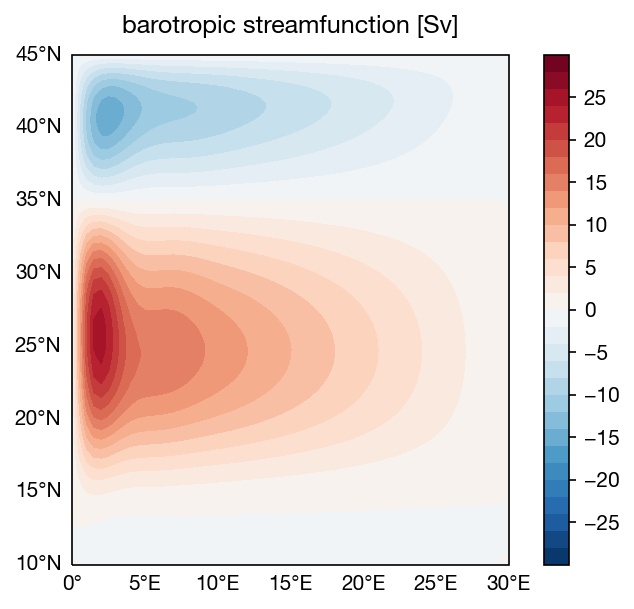

In [54]:
fld = psiB.isel(time=-1)

vmax = 30
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
setup_plan_plot(ax)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax.set_aspect(1)
fig.colorbar(cs, ax=ax, ticks=np.arange(-25, 26, 5))
ax.set_title('barotropic streamfunction [Sv]')

fig.savefig('barotropic_streamfunction.pdf', bbox_inches='tight')

### Layerwise

In [55]:
psi = grid_op.cumsum(cont.vh.isel(time=-1), axis='X', to='outer', boundary='fill')/1e6

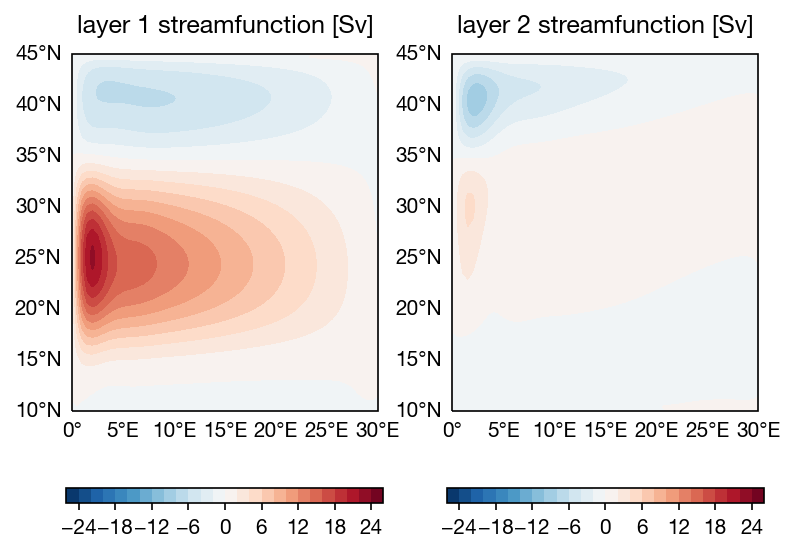

In [56]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})

ax = axs[0]
setup_plan_plot(ax)
vmax = 26
vmin = -vmax
levels = np.arange(vmin, vmax+1, 2)
cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
fig.colorbar(cs, ax=ax, orientation='horizontal')
ax.set_title('layer 1 streamfunction [Sv]')

ax = axs[1]
setup_plan_plot(ax)
cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
fig.colorbar(cs, ax=ax, orientation='horizontal')
ax.set_title('layer 2 streamfunction [Sv]')

fig.savefig('layer_streamfunctions.pdf', bbox_inches='tight')

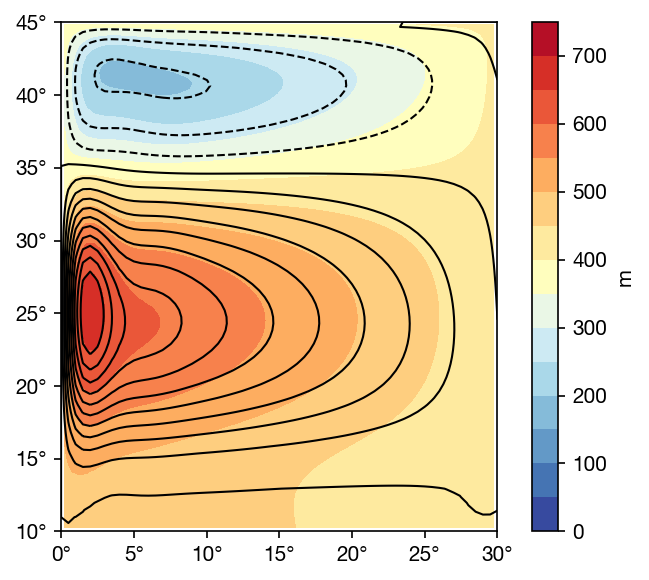

In [59]:
vmin = 0
vmax = 750
levels = np.arange(vmin, vmax+1, 50)

fig, ax = plt.subplots()

h = prog.h.isel(zl=0, time=-1)
cs = ax.contourf(h.xh, h.yh, h, levels=levels, vmin=vmin, vmax=vmax)
ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.contour(lon, lat, psi2, levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.plot(np.rad2deg(λo), lat, ls='-', color='tab:gray', lw=2)

fig.colorbar(cs, label='m')

yticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_yticks(yticks)
ax.set_yticklabels(latFormatter.format(yticks))

xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))

ax.set_aspect(1)

fig.savefig('thickness_psi_mom.pdf', bbox_inches='tight')

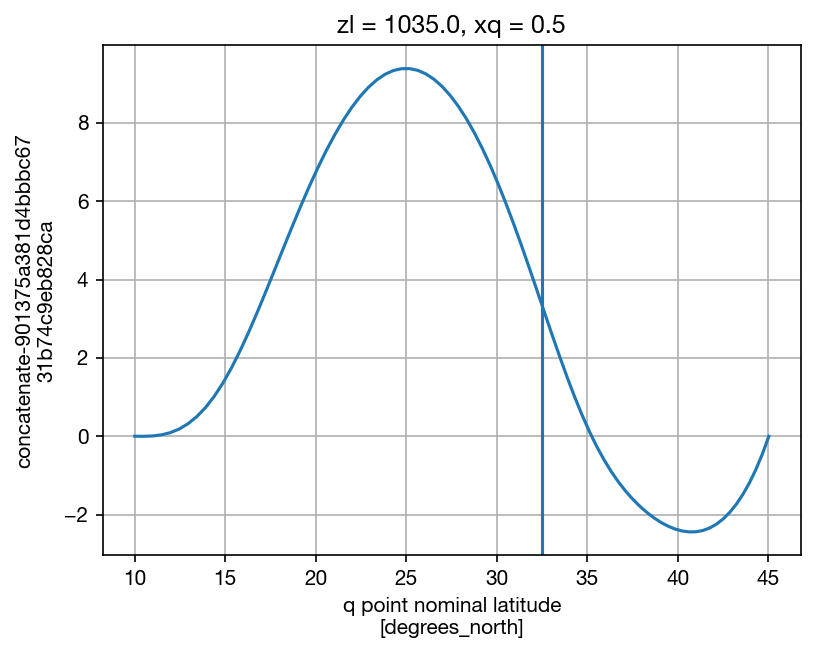

In [60]:
psi.isel(zl=0,xq=1).plot()
plt.grid()
plt.axvline(32.5)

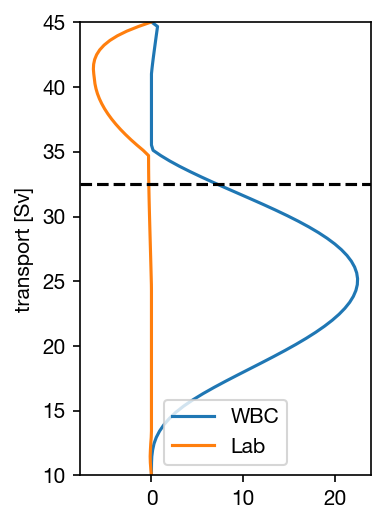

In [61]:
T_wbc = psi.isel(zl=0).max(dim='xq')
T_lab = psi.isel(zl=0).min(dim='xq')

fig, ax = plt.subplots(figsize=(2.5,4))

ax.plot(T_wbc, T_wbc.yq, label='WBC')
ax.plot(T_lab, T_wbc.yq, label='Lab')
ax.set_ylabel('transport [Sv]')

ax.set_ylim([10, 45])
ax.legend(loc='lower center')
ax.axhline(32.5, color='k', ls='--')

fig.savefig('outcrop_transports_mom.pdf', bbox_inches='tight')

## Velocities

In [65]:
speed.isel(zl=1).max().values

array(1.8968287, dtype=float32)

In [62]:
u = 100*grid_op.interp(prog.u.isel(time=-1), 'X')
v = 100*grid_op.interp(prog.v.isel(time=-1), 'Y')

speed = np.sqrt(u**2 + v**2)

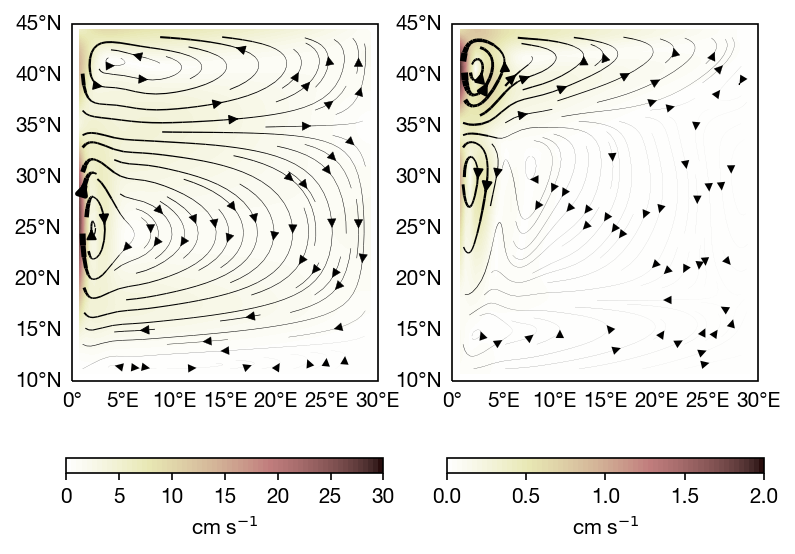

In [67]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

vm = [30, 2]
cticks = [np.arange(0, 31, 5), np.arange(0, 2.5, .5)]
for zl in range(2):
    ax = axs[zl]
    setup_plan_plot(ax)
    vmax = vm[zl]
    vmin = 0
    levels = np.linspace(vmin, vmax, 64)

    lw = (5*speed.isel(zl=zl) / vmax).values

    cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
                          vmin=vmin, vmax=vmax, cmap='pink_r',
                          transform=data_projection)
    sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
                  transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
    fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$')

fig.savefig('velocities.pdf', bbox_inches='tight')

## Meridional Sections

In [1]:
xlocs = [0, 5, 15, 25, 30]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

flds = prog.isel(time=-1)

e = flds.e
u = 100*grid_op.interp(flds.u, 'X')
vms = [42, 42, 5, 5, 1, 1]
for xloc, ax, vmax in zip(xlocs, axs, vms):
    for zi in range(3):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        flds.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        u.sel(xh=xloc, method='nearest').values, representation='plm')
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:d}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])

fig.savefig('meridional_u.pdf', bbox_inches='tight')

NameError: name 'plt' is not defined

## Zonal Sections

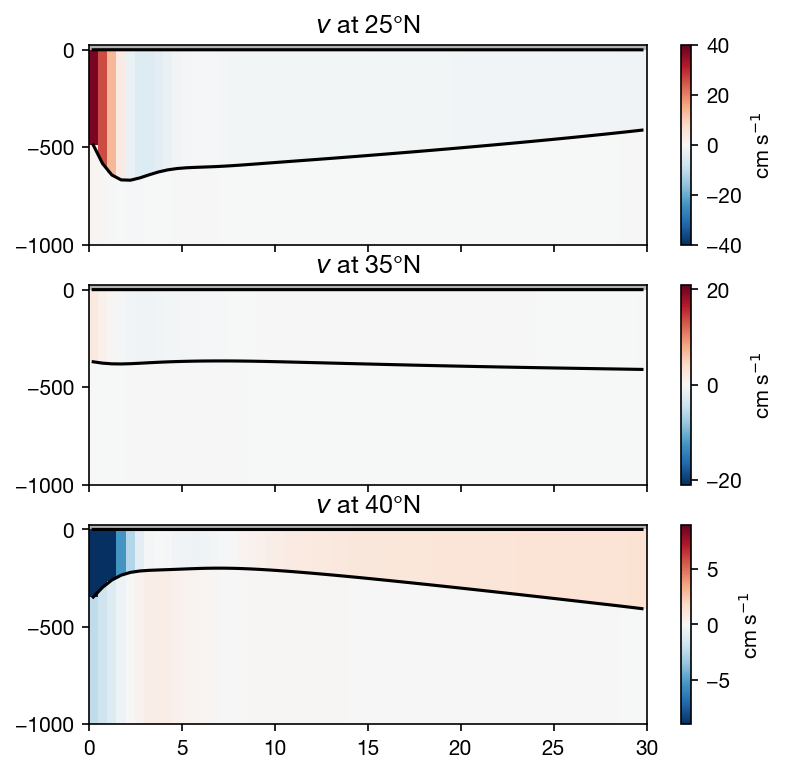

In [69]:
ylocs = [25, 35, 40]

fig, axs = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(6,6))

flds = prog.isel(time=-1)

e = flds.e
v = 100*grid_op.interp(flds.v, 'Y')
vms = [40, 21, 9]
for yloc, ax, vmax in zip(ylocs, axs, vms):
    ax.set_facecolor('.7')
    for zi in range(2):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        flds.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        v.sel(yh=yloc, method='nearest').values, representation='plm')
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_title('$v$ at {:d}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])

fig.savefig('zonal_v.pdf', bbox_inches='tight')